In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 99.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=20883804c29dae8ea806dbb8f88877f10d8ae43ef1f9700043deb399bbba34a6
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
# Imports

import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import os
import time
from sklearn.metrics import classification_report, accuracy_score, f1_score
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
# Importing Datasets from Kaggle

# kaggle api token can be generated in your profile settings : https://www.kaggle.com/settings
# save kaggle api token in secrets

from google.colab import userdata
!export KAGGLE_API_TOKEN={userdata.get('KAGGLE_API_TOKEN')}

import kagglehub

# Download latest version of datasets
ds2 = kagglehub.dataset_download("jeftaadriel/oia-odir-dataset")
print(ds2)

Using Colab cache for faster access to the 'oia-odir-dataset' dataset.
/kaggle/input/oia-odir-dataset


In [ ]:
# Convert files to csv format
off_site_file = pd.read_excel(f"{ds2}/Off-site Test Set/Annotation/off-site test annotation (English).xlsx")
off_site_file.to_csv("off_site_test_annotation.csv", index=None, header=True)

on_site_file = pd.read_excel(f"{ds2}/On-site Test Set/Annotation/on-site test annotation (English).xlsx")
on_site_file.to_csv("on_site_test_annotation.csv", index=None, header=True)

training_file = pd.read_excel(f"{ds2}/Training Set/Annotation/training annotation (English).xlsx")
training_file.to_csv("training_annotation.csv", index=None, header=True)

# Base paths for images
base_path_off_site = ds2 + '/Off-site Test Set/Images/'
base_path_on_site = ds2 + '/On-site Test Set/Images/'
base_path_training = ds2 + '/Training Set/Images/'

# Add image paths to a DataFrame
def process_fundus_image_paths(df, base_path, left_col='Left-Fundus', right_col='Right-Fundus'):
    def add_image_path(filename, current_base_path):
        if pd.isna(filename):
            return filename
        return os.path.join(current_base_path, filename)

    df[left_col] = df[left_col].apply(lambda x: add_image_path(x, base_path))
    df[right_col] = df[right_col].apply(lambda x: add_image_path(x, base_path))
    return df

# Apply to each DataFrame
off_site_file = process_fundus_image_paths(off_site_file, base_path_off_site)
on_site_file = process_fundus_image_paths(on_site_file, base_path_on_site)
training_file = process_fundus_image_paths(training_file, base_path_training)

# Combine all DataFrames into one
df_ds2 = pd.concat([off_site_file, on_site_file, training_file], ignore_index=True)

# Remove specified columns
columns_to_remove = ['ID', 'Patient Age', 'Patient Sex', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
df_ds2 = df_ds2.drop(columns=columns_to_remove)

# Convert Keywords into diagnosis for each eye
disease_mapping = {
    'normal': 'NORMAL',
    'diabetic retinopathy': 'DIABETIC_RETINOPATHY',
    'glaucoma': 'GLAUCOMA',
    'cataract': 'CATARACT',
    'macular degeneration': 'AGE_RELATED_MACULAR_DEGENERATION',
    'age-related macular degeneration': 'AGE_RELATED_MACULAR_DEGENERATION',
    'hypertensive retinopathy': 'HYPERTENSION',
    'myopia': 'MYOPIA',
}

df_left = df_ds2[['Left-Fundus', 'Left-Diagnostic Keywords']].copy()
df_right = df_ds2[['Right-Fundus', 'Right-Diagnostic Keywords']].copy()

df_left.columns = ['image_path', 'eye_disease']
df_right.columns = ['image_path', 'eye_disease']

# Get unique disease codes for column names
disease_codes = list(set(disease_mapping.values()))
disease_codes.append('OTHER_DISEASES')

def parse_diagnosis(df):
    # Initialize all disease columns with 0
    for disease in disease_codes:
        df[disease] = 0

    # Parse each row's diagnostic keywords
    for idx, keywords in df['eye_disease'].items():
        if pd.isna(keywords):
            continue

        # Convert to lowercase for matching
        keywords_lower = str(keywords).lower()

        disease_found = False

        # Check for each disease keyword in the mapping
        for keyword, disease_code in disease_mapping.items():
            if keyword in keywords_lower:
                df.at[idx, disease_code] = 1
                disease_found = True

        if not disease_found:
            df.at[idx, 'OTHER_DISEASES'] = 1

    df = df.drop('eye_disease', axis=1)

    return df

# Apply to both dataframes
df_left = parse_diagnosis(df_left)
df_right = parse_diagnosis(df_right)

# Combine to final dataset
df_ds2 = pd.concat([df_left, df_right], ignore_index=True)

print(df_left)
print(df_right)


                                             image_path  ...  OTHER_DISEASES
0     /kaggle/input/oia-odir-dataset/Off-site Test S...  ...               0
1     /kaggle/input/oia-odir-dataset/Off-site Test S...  ...               1
2     /kaggle/input/oia-odir-dataset/Off-site Test S...  ...               1
3     /kaggle/input/oia-odir-dataset/Off-site Test S...  ...               1
4     /kaggle/input/oia-odir-dataset/Off-site Test S...  ...               1
...                                                 ...  ...             ...
4995  /kaggle/input/oia-odir-dataset/Training Set/Im...  ...               1
4996  /kaggle/input/oia-odir-dataset/Training Set/Im...  ...               1
4997  /kaggle/input/oia-odir-dataset/Training Set/Im...  ...               1
4998  /kaggle/input/oia-odir-dataset/Training Set/Im...  ...               1
4999  /kaggle/input/oia-odir-dataset/Training Set/Im...  ...               0

[5000 rows x 9 columns]
                                             image_

In [ ]:
class EyeDiseaseDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        self.labels = self.dataframe.iloc[:, 1:].values.astype(float) # Get disease labels as numpy array

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0] # First column is image_path
        image = Image.open(img_path).convert('RGB')
        labels = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, labels

In [ ]:
def crop_black_borders(image):
    # Convert PIL Image to NumPy array
    img_np = np.array(image)

    # Threshold for black pixels
    # Pixels with R, G, B values all below this threshold will be considered black
    BLACK_THRESHOLD = 10

    non_black_pixels = np.any(img_np > BLACK_THRESHOLD, axis=2)

    # Find rows and columns that contain non-black pixels
    rows = np.any(non_black_pixels, axis=1)
    cols = np.any(non_black_pixels, axis=0)

    # Get the min/max indices for cropping
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    # Crop the NumPy array
    cropped_img_np = img_np[rmin:rmax+1, cmin:cmax+1]

    # Convert back to PIL Image
    return Image.fromarray(cropped_img_np)

In [ ]:
data_transforms = transforms.Compose([
    transforms.Lambda(crop_black_borders), # Apply custom cropping function
    transforms.Resize((224, 224)), # Resize images to 224x224 pixels
    transforms.ToTensor(), # Convert PIL image to PyTorch tensor
])


In [ ]:
BATCH_SIZE = 128
NUM_EPOCHS = 20
LR = 1e-4
NUM_WORKERS = 2
IMAGE_SIZE=224

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAVE_PATH = "best_efficientnet_b0.pth"

SEED = 68

In [ ]:
def set_seed(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
set_seed(SEED)

In [ ]:
class_names = [
    "HYPERTENSION",
    "CATARACT",
    "AGE_RELATED_MACULAR_DEGENERATION",
    "GLAUCOMA",
    "MYOPIA",
    "DIABETIC_RETINOPATHY",
    "NORMAL",
    "OTHER_DISEASES",
]

df = df_ds2.copy()
# only keep rows with one label
df["num_labels"] = df[disease_cols].sum(axis=1)
df_single = df[df["num_labels"] == 1].copy()

# convert one hot into target
df_single["target_name"] = df_single[disease_cols].idxmax(axis=1)

label_to_idx = {label: idx for idx, label in enumerate(class_names)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

df_single["target"] = df_single["target_name"].map(label_to_idx)

# Keep only rows whose image path exists
df_single = df_single[df_single["image_path"].apply(lambda x: isinstance(x, str))].copy()
df_single = df_single.reset_index(drop=True)

print("Original rows:", len(df))
print("Single-label rows kept:", len(df_single))
print(df_single[["image_path", "target_name", "target"]].head())

Original rows: 10000
Single-label rows kept: 9895
                                          image_path     target_name  target
0  /kaggle/input/oia-odir-dataset/Off-site Test S...    HYPERTENSION       0
1  /kaggle/input/oia-odir-dataset/Off-site Test S...  OTHER_DISEASES       7
2  /kaggle/input/oia-odir-dataset/Off-site Test S...  OTHER_DISEASES       7
3  /kaggle/input/oia-odir-dataset/Off-site Test S...  OTHER_DISEASES       7
4  /kaggle/input/oia-odir-dataset/Off-site Test S...  OTHER_DISEASES       7


In [ ]:
train_df, test_df = train_test_split(
    df_single,
    test_size=0.2,
    stratify=df_single["target"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(test_df))
test_df.head()

Train size: 7916
Val size: 1979


,image_path,HYPERTENSION,GLAUCOMA,NORMAL,CATARACT,AGE_RELATED_MACULAR_DEGENERATION,MYOPIA,DIABETIC_RETINOPATHY,OTHER_DISEASES,num_labels,target_name,target
0,/kaggle/input/oia-odir-dataset/Off-site Test S...,0,0,0,0,0,1,0,0,1,MYOPIA,4
1,/kaggle/input/oia-odir-dataset/Training Set/Im...,0,0,0,0,0,0,0,1,1,OTHER_DISEASES,7
2,/kaggle/input/oia-odir-dataset/On-site Test Se...,0,0,0,0,0,0,0,1,1,OTHER_DISEASES,7
3,/kaggle/input/oia-odir-dataset/Training Set/Im...,0,0,1,0,0,0,0,0,1,NORMAL,6
4,/kaggle/input/oia-odir-dataset/On-site Test Se...,0,0,0,0,0,0,0,1,1,OTHER_DISEASES,7


In [ ]:
class ODIRDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.dataframe)

    def __getitem__(self, idx: int):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        target = int(row["target"])

        if self.transform is not None:
            image = self.transform(image)

        return image, target

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [ ]:
train_dataset = ODIRDataset(train_df, transform=train_transform)
test_dataset = ODIRDataset(test_df, transform=test_transform)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

In [ ]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, len(class_names))

model = model.to(DEVICE)
print(model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 228MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=8, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

/tmp/ipykernel_3516/3458732452.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_targets = []

    progress_bar = tqdm(loader, desc="Train", leave=False)

    for images, targets in progress_bar:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_targets = []

    progress_bar = tqdm(loader, desc="Val", leave=False)

    for images, targets in progress_bar:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=(device == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, targets)

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_targets, all_preds)
    epoch_f1 = f1_score(all_targets, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1, all_targets, all_preds

In [ ]:
best_test_f1 = -1.0
history = []

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")

    train_loss, train_acc, train_f1 = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=DEVICE,
    )

    test_loss, test_acc, test_f1, test_targets, test_preds = validate_one_epoch(
        model=model,
        loader=test_loader,
        criterion=criterion,
        device=DEVICE,
    )

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1,
    })

    print(
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | train_f1={train_f1:.4f}"
    )
    print(
        f"test_loss={test_loss:.4f} | test_acc={test_acc:.4f} | test_f1={test_f1:.4f}"
    )

    if test_f1 > best_test_f1:
        best_test_f1 = test_f1
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_names": class_names,
                "label_to_idx": label_to_idx,
            },
            SAVE_PATH,
        )
        print("Saved best model")


Epoch 1/20


Train:   0%|          | 0/62 [00:00<?, ?it/s]/tmp/ipykernel_3516/152756203.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):
Val:   0%|          | 0/16 [00:00<?, ?it/s]/tmp/ipykernel_3516/152756203.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


train_loss=1.5483 | train_acc=0.4572 | train_f1=0.4317
test_loss=1.5896 | test_acc=0.3517 | test_f1=0.3202
Saved best model

Epoch 2/20


Train:   0%|          | 0/62 [00:00<?, ?it/s]/tmp/ipykernel_3516/152756203.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):
Val:   0%|          | 0/16 [00:00<?, ?it/s]/tmp/ipykernel_3516/152756203.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


train_loss=1.0077 | train_acc=0.6473 | train_f1=0.6216
test_loss=1.4144 | test_acc=0.4174 | test_f1=0.3776
Saved best model

Epoch 3/20


...

train_loss=0.1787 | train_acc=0.9264 | train_f1=0.9246
test_loss=1.1781 | test_acc=0.6114 | test_f1=0.5366
Saved best model

Epoch 19/20


Train:   0%|          | 0/62 [00:00<?, ?it/s]/tmp/ipykernel_3516/152756203.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):
Val:   0%|          | 0/16 [00:00<?, ?it/s]/tmp/ipykernel_3516/152756203.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):


train_loss=0.1748 | train_acc=0.9285 | train_f1=0.9275
test_loss=1.1972 | test_acc=0.6276 | test_f1=0.5143

Epoch 20/20


Train:   0%|          | 0/62 [00:00<?, ?it/s]/tmp/ipykernel_3516/152756203.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):
Val:   0%|          | 0/16 [00:00<?, ?it/s]/tmp/ipykernel_3516/152756203.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device == "cuda")):
                                                    

train_loss=0.1799 | train_acc=0.9241 | train_f1=0.9232
test_loss=1.2187 | test_acc=0.6180 | test_f1=0.5228


In [ ]:
@torch.no_grad()
def predict_image(image_path: str, model, class_names, device):
    transform = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])

    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    outputs = model(image_tensor)
    probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    pred_idx = int(np.argmax(probs))
    pred_label = class_names[pred_idx]

    return pred_label, probs

In [ ]:
sample_path = test_df.iloc[0]["image_path"]
pred_label, probs = predict_image(sample_path, model, class_names, DEVICE)

print("Image path:", sample_path)
print("Predicted class:", pred_label)
print("Probabilities:", probs)

Image path: /kaggle/input/oia-odir-dataset/Off-site Test Set/Images/1684_left.jpg
Predicted class: MYOPIA
Probabilities: [3.3487607e-04 4.7379846e-04 4.6598274e-04 2.3367417e-04 9.9678838e-01
 6.0263346e-04 1.6562728e-04 9.3509664e-04]


In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT_PATH = "model.pth"

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

class_names = checkpoint["class_names"]
label_to_idx = checkpoint["label_to_idx"]

model = models.efficientnet_b0(weights=None)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, len(class_names))

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print(class_names)

['HYPERTENSION', 'CATARACT', 'AGE_RELATED_MACULAR_DEGENERATION', 'GLAUCOMA', 'MYOPIA', 'DIABETIC_RETINOPATHY', 'NORMAL', 'OTHER_DISEASES']


In [ ]:
from sklearn.metrics import accuracy_score, classification_report
all_preds = []
all_labels = []

with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(DEVICE)
    labels = labels.to(DEVICE)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
))

                                  precision    recall  f1-score   support

                    HYPERTENSION     0.3125    0.2174    0.2564        46
                        CATARACT     0.7426    0.8427    0.7895        89
AGE_RELATED_MACULAR_DEGENERATION     0.5345    0.4306    0.4769        72
                        GLAUCOMA     0.5172    0.5625    0.5389        80
                          MYOPIA     0.6974    0.7571    0.7260        70
            DIABETIC_RETINOPATHY     0.5000    0.0588    0.1053        17
                          NORMAL     0.6469    0.6743    0.6603       872
                  OTHER_DISEASES     0.5686    0.5539    0.5612       733

                        accuracy                         0.6109      1979
                       macro avg     0.5650    0.5122    0.5143      1979
                    weighted avg     0.6056    0.6109    0.6060      1979



In [ ]:
IMAGE_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

def load_image_for_cam(image_path):
    pil_img = Image.open(image_path).convert("RGB")
    pil_img = pil_img.resize((IMAGE_SIZE, IMAGE_SIZE))

    rgb_img = np.array(pil_img).astype(np.float32) / 255.0
    input_tensor = transform(pil_img).unsqueeze(0)

    return rgb_img, input_tensor

In [ ]:
target_layers = [model.features[-1]]
print(target_layers)

[Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)]


In [ ]:
def generate_gradcam(image_path, target_class_idx=None):
    rgb_img, input_tensor = load_image_for_cam(image_path)
    input_tensor = input_tensor.to(DEVICE)

    with torch.no_grad():
        logits = model(input_tensor)
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
        pred_idx = int(np.argmax(probs))

    if target_class_idx is None:
        target_class_idx = pred_idx

    targets = [ClassifierOutputTarget(target_class_idx)]

    cam = GradCAM(model=model, target_layers=target_layers)
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    return {
        "rgb_img": rgb_img,
        "cam_overlay": visualization,
        "grayscale_cam": grayscale_cam,
        "pred_idx": pred_idx,
        "pred_label": class_names[pred_idx],
        "target_idx": target_class_idx,
        "target_label": class_names[target_class_idx],
        "probs": probs,
    }

In [ ]:
sample_path = test_df.iloc[0]["image_path"]   # or any file path you want

result = generate_gradcam(sample_path)

print("Predicted class:", result["pred_label"])
print("Target class for CAM:", result["target_label"])
print("Probabilities:")
for cls, p in zip(class_names, result["probs"]):
    print(f"{cls}: {p:.4f}")

Predicted class: MYOPIA
Target class for CAM: MYOPIA
Probabilities:
HYPERTENSION: 0.0003
CATARACT: 0.0005
AGE_RELATED_MACULAR_DEGENERATION: 0.0005
GLAUCOMA: 0.0003
MYOPIA: 0.9966
DIABETIC_RETINOPATHY: 0.0006
NORMAL: 0.0002
OTHER_DISEASES: 0.0010


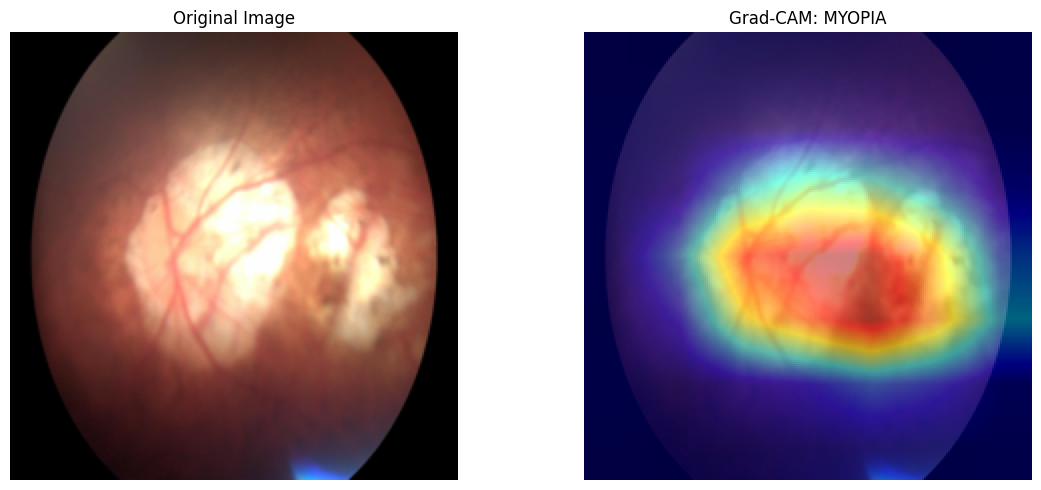

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(result["rgb_img"])
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(result["cam_overlay"])
axes[1].set_title(f"Grad-CAM: {result['target_label']}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

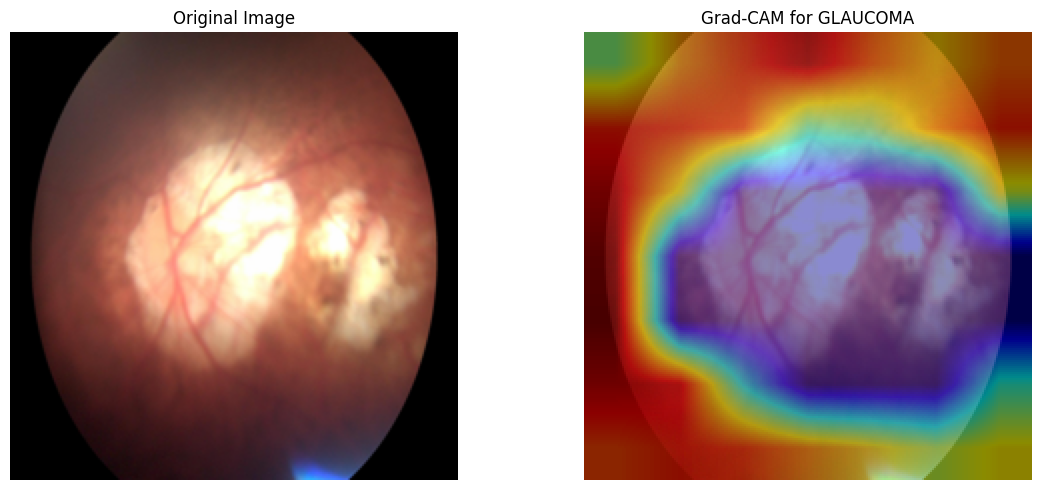

In [ ]:
glaucoma_idx = label_to_idx["GLAUCOMA"]

result_glaucoma = generate_gradcam(sample_path, target_class_idx=glaucoma_idx)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(result_glaucoma["rgb_img"])
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(result_glaucoma["cam_overlay"])
axes[1].set_title("Grad-CAM for GLAUCOMA")
axes[1].axis("off")

plt.tight_layout()
plt.show()